<a href="https://colab.research.google.com/github/Rishik27-12/NLP/blob/main/2403A52263_Assign_11ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

import the libs

In [1]:
import pandas as pd


import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

Load and Preprocess Data



In [5]:
df=pd.read_csv('/content/IMDB Dataset.csv', engine='python')

In [6]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [10]:
import nltk
from nltk.corpus import stopwords
import re # Import the regular expression module

# Download stopwords if not already downloaded
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    # Convert to lowercase
    text = text.lower()
    # Remove HTML tags (specific to IMDB dataset) using regex
    # Removed problematic line: text = re.sub(r'', ' ', text)
    text = re.sub(r'<.*?>', ' ', text)
    # Remove non-alphabetic characters (using regex)
    text = re.sub(r'[^a-z\s]', '', text)
    # Replace multiple spaces with a single space and strip leading/trailing spaces
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    # Filter out stopwords and single character words (e.g., 'a', 'i')
    filtered_words = [word for word in words if word not in stop_words and len(word) > 1]
    return " ".join(filtered_words)

df['processed_review'] = df['review'].apply(remove_stopwords)

print("Text cleaned and stopwords removed using 're' module for initial cleaning. A new column 'processed_review' has been created.")

Text cleaned and stopwords removed using 're' module for initial cleaning. A new column 'processed_review' has been created.


In [8]:
df['processed_review'].head()

,processed_review
0,
1,
2,
3,
4,


In [15]:
vocabulary_size = len(tfidf_vectorizer.vocabulary_)
print(f"Vocabulary size: {vocabulary_size}")

Vocabulary size: 5000


LOGISTIC REGRESSION

In [16]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Train Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000, solver='liblinear') # Increased max_iter for convergence, using 'liblinear' for small datasets (or when L1/L2 penalties are used)
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

X_train shape: (40000, 5000)
X_test shape: (10000, 5000)
y_train shape: (40000,)
y_test shape: (10000,)
Logistic Regression model trained successfully.


In [17]:
# Make predictions on the test set
y_pred = logistic_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)

Model Accuracy: 0.8893

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [18]:
# Make predictions on the test set
y_pred = logistic_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)

Model Accuracy: 0.8893

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [19]:
# Make predictions on the test set
y_pred = logistic_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)

Model Accuracy: 0.8893

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [11]:
df['processed_review'].head()

,processed_review
0,one reviewers mentioned watching oz episode yo...
1,wonderful little production filming technique ...
2,thought wonderful way spend time hot summer we...
3,basically theres family little boy jake thinks...
4,petter matteis love time money visually stunni...


In [12]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting to 5000 features for demonstration
X = tfidf_vectorizer.fit_transform(df['processed_review'])
y = df['sentiment'].apply(lambda x: 1 if x == 'positive' else 0) # Convert sentiment to numerical (0 for negative, 1 for positive)

print("TF-IDF vectorization complete. Shape of X (features):", X.shape)
print("Shape of y (target variable):", y.shape)

TF-IDF vectorization complete. Shape of X (features): (50000, 5000)
Shape of y (target variable): (50000,)


In [13]:
vocabulary_size = len(tfidf_vectorizer.vocabulary_)
print(f"Vocabulary size: {vocabulary_size}")

Vocabulary size: 5000


In [14]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Train Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000, solver='liblinear') # Increased max_iter for convergence, using 'liblinear' for small datasets (or when L1/L2 penalties are used)
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

X_train shape: (40000, 5000)
X_test shape: (10000, 5000)
y_train shape: (40000,)
y_test shape: (10000,)
Logistic Regression model trained successfully.


Accuracy: 0.8893

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000


Confusion Matrix:
[[4342  619]
 [ 488 4551]]


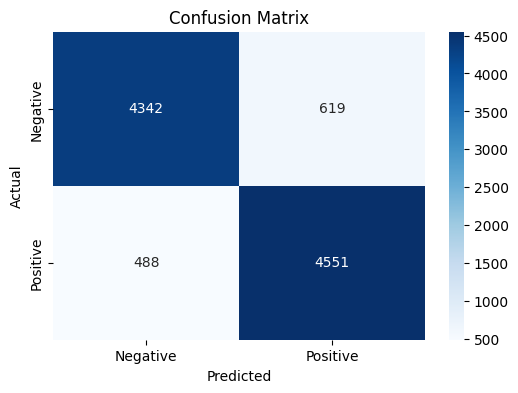

In [20]:
# Make predictions on the test set
y_pred = logistic_model.predict(X_test)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Calculate Precision, Recall, F1-score
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()